# 랜덤포레스트


## 학습 목표

**앙상블 학습의 개념 이해** 집단 지성 원리와 배깅/부스팅의 차이를 설명함

**랜덤포레스트 원리 파악** 두 가지 랜덤(데이터, 특성)과 투표 메커니즘을 이해함

**수학적 배경 습득** 배깅 예측 공식과 OOB 오차 계산을 수식으로 표현함

**실습 능력 배양** RandomForestClassifier로 안정적인 분류 모델을 구축함

# 1. 앙상블 학습의 이론적 배경

## 1.1 앙상블(Ensemble) 학습이란?

### 정의

앙상블 학습은 **여러 개의 기본 모델(base learner)** 을 결합하여 단일 모델보다 **더 정확하고 안정적인 예측**을 수행하는 기계학습 기법임.

### 일상적 비유

| 상황 | 단일 모델 | 앙상블 모델 |
|------|----------|------------|
| 의료 진단 | 한 명의 의사 소견 | **여러 전문의의 협진** |
| 투자 결정 | 한 명의 분석가 의견 | **다수 분석가의 종합 의견** |
| 시험 평가 | 한 번의 시험 결과 | **여러 번 시험의 평균** |
| 제품 검사 | 한 명의 검사원 | **다수 검사원의 교차 검증** |

### 집단 지성(Wisdom of Crowds)의 수학적 원리

#### Francis Galton의 황소 무게 맞추기 실험 (1906년)

영국 플리머스에서 열린 가축 박람회에서 약 800명의 참가자가 황소의 무게를 추측하는 대회가 열렸음. 개별 추측값은 큰 오차를 보였지만, **전체 참가자의 중앙값(1,207파운드)**은 실제 무게(1,198파운드)와 **0.8%** 오차에 불과했음.

#### 수학적 설명: 오차 상쇄의 원리

각 모델 $f_i(x)$의 예측을 다음과 같이 분해할 수 있음:

$$f_i(x) = y_{true} + \epsilon_i$$

여기서:
- $y_{true}$: 실제 값
- $\epsilon_i$: i번째 모델의 오차

**B개 모델의 평균 예측**:

$$\bar{f}(x) = \frac{1}{B}\sum_{i=1}^{B}f_i(x) = y_{true} + \frac{1}{B}\sum_{i=1}^{B}\epsilon_i$$

**핵심 가정**: 각 모델의 오차 $\epsilon_i$가 서로 **독립적**이고 **기댓값이 0**이면:

$$E\left[\frac{1}{B}\sum_{i=1}^{B}\epsilon_i\right] = \frac{1}{B}\sum_{i=1}^{B}E[\epsilon_i] = 0$$

**분산의 감소**:

$$Var\left(\frac{1}{B}\sum_{i=1}^{B}\epsilon_i\right) = \frac{1}{B^2}\sum_{i=1}^{B}Var(\epsilon_i) = \frac{\sigma^2}{B}$$

결론: 모델 수 B가 증가하면 **분산이 $\frac{1}{B}$로 감소**함.

### 좋은 앙상블의 두 가지 조건

| 조건 | 수학적 표현 | 의미 |
|------|------------|------|
| **정확성(Accuracy)** | $E[\epsilon_i] \approx 0$ | 각 모델이 랜덤 추측보다 나아야 함 |
| **다양성(Diversity)** | $Cov(\epsilon_i, \epsilon_j) \approx 0$ | 모델들이 서로 다른 오류를 내야 함 |

**상관관계가 있는 경우의 분산**:

$$Var\left(\frac{1}{B}\sum_{i=1}^{B}f_i\right) = \rho\sigma^2 + \frac{1-\rho}{B}\sigma^2$$

여기서:
- $\rho$: 모델 간 평균 상관계수 $(0 \leq \rho \leq 1)$
- $\sigma^2$: 개별 모델의 분산

**해석**:
- $\rho = 0$ (완전 독립): $Var = \frac{\sigma^2}{B}$ (최대 분산 감소)
- $\rho = 1$ (완전 상관): $Var = \sigma^2$ (분산 감소 없음)

따라서 앙상블 효과를 극대화하려면 **모델 간 상관관계를 최소화**해야 함.

## 1.2 앙상블 방법의 분류

```mermaid
flowchart TD
    A[앙상블 방법] --> B[배깅 Bagging]
    A --> C[부스팅 Boosting]
    A --> D[스태킹 Stacking]

    B --> B1["병렬 학습<br/>(독립적)"]
    B --> B2[대표: 랜덤포레스트]
    B --> B3[목표: 분산 감소]

    C --> C1["순차 학습<br/>(의존적)"]
    C --> C2[대표: XGBoost, LightGBM]
    C --> C3[목표: 편향 감소]

    D --> D1["계층 학습<br/>(메타 모델)"]
    D --> D2[대표: 스태킹 앙상블]
    D --> D3[목표: 다양한 모델 결합]
```

### 배깅(Bagging) vs 부스팅(Boosting) 상세 비교

| 구분 | 배깅 (Bagging) | 부스팅 (Boosting) |
|------|---------------|------------------|
| **Full Name** | Bootstrap Aggregating | - |
| **학습 방식** | 병렬 (독립) | 순차 (의존) |
| **데이터 샘플링** | 부트스트랩 (복원 추출) | 가중치 조정 |
| **주요 목표** | **분산(Variance) 감소** | **편향(Bias) 감소** |
| **기본 모델** | 복잡한 모델 (깊은 트리) | 단순한 모델 (얕은 트리) |
| **대표 알고리즘** | 랜덤포레스트 | XGBoost, LightGBM, AdaBoost |
| **과대적합 위험** | 낮음 | 주의 필요 |
| **병렬 처리** | 가능 | 제한적 |
| **학습 속도** | 빠름 | 상대적으로 느림 |

## 1.3 배깅(Bagging)의 수학적 원리

### 부트스트랩 샘플링(Bootstrap Sampling)

원본 데이터셋 $D = \{(x_1, y_1), (x_2, y_2), \ldots, (x_n, y_n)\}$에서 **복원 추출**로 새로운 데이터셋을 생성하는 방식임.

```mermaid
flowchart LR
    A["원본 데이터<br/>n개 샘플"] --> B1["부트스트랩 1<br/>n개 복원추출"]
    A --> B2["부트스트랩 2<br/>n개 복원추출"]
    A --> B3["...<br/>..."]
    A --> BB["부트스트랩 B<br/>n개 복원추출"]
    
    B1 --> T1[모델 1]
    B2 --> T2[모델 2]
    B3 --> T3[...]
    BB --> TB[모델 B]
    
    T1 --> V["집계<br/>(투표/평균)"]
    T2 --> V
    T3 --> V
    TB --> V
    
    V --> P[최종 예측]
```

### 예시: 5개 샘플에서 부트스트랩

원본 데이터: $D = \{A, B, C, D, E\}$

| 부트스트랩 | 추출 결과 | 포함된 원본 | 제외된 원본 |
|-----------|----------|------------|------------|
| 샘플 1 | {A, A, C, D, E} | A, C, D, E | **B** |
| 샘플 2 | {B, C, C, E, E} | B, C, E | **A, D** |
| 샘플 3 | {A, B, D, D, D} | A, B, D | **C, E** |

### 부트스트랩에서 특정 샘플이 제외될 확률

n개의 데이터에서 n번 복원 추출할 때, 특정 샘플 $x_i$가 **한 번도 선택되지 않을 확률**:

$$P(x_i \text{ 제외}) = \left(1 - \frac{1}{n}\right)^n$$

**극한값 계산**:

$$\lim_{n \to \infty} \left(1 - \frac{1}{n}\right)^n = e^{-1} \approx 0.368$$

**증명** (로그 극한 이용):

$$\ln\left[\left(1 - \frac{1}{n}\right)^n\right] = n \cdot \ln\left(1 - \frac{1}{n}\right)$$

테일러 전개: $\ln(1-x) \approx -x - \frac{x^2}{2} - \cdots$ (x가 작을 때)

$$n \cdot \ln\left(1 - \frac{1}{n}\right) \approx n \cdot \left(-\frac{1}{n} - \frac{1}{2n^2} - \cdots\right) \approx -1$$

따라서: $\left(1 - \frac{1}{n}\right)^n \approx e^{-1} \approx 0.368$

**결론**: 데이터 크기와 무관하게 각 부트스트랩 샘플에서 약 **36.8%의 데이터가 제외됨**.

In [1]:
# 부트스트랩 샘플링의 제외 확률 실험
import numpy as np
import matplotlib.pyplot as plt

# 한글 폰트 설정
plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

# 다양한 n에 대해 실험
n_values = [10, 50, 100, 500, 1000, 5000]
n_bootstrap = 1000  # 각 n에 대해 1000번 부트스트랩 반복

print("=" * 65)
print("부트스트랩 샘플링: 이론값 vs 실험값 비교")
print("=" * 65)
print(f"{'데이터 크기 n':>12} | {'이론적 제외율':>15} | {'실험적 제외율':>15} | {'오차':>10}")
print("-" * 65)

theoretical_values = []
experimental_values = []

for n in n_values:
    # 이론값
    theoretical = (1 - 1/n) ** n
    theoretical_values.append(theoretical)
    
    # 실험값: n_bootstrap번 부트스트랩하여 평균 제외율 계산
    exclusion_counts = []
    for _ in range(n_bootstrap):
        bootstrap_indices = np.random.choice(n, size=n, replace=True)
        unique_indices = len(np.unique(bootstrap_indices))
        excluded = n - unique_indices
        exclusion_counts.append(excluded / n)
    
    experimental = np.mean(exclusion_counts)
    experimental_values.append(experimental)
    
    error = abs(theoretical - experimental)
    print(f"{n:>12} | {theoretical:>15.6f} | {experimental:>15.6f} | {error:>10.6f}")

print("-" * 65)
print(f"{'e^(-1)':>12} | {np.exp(-1):>15.6f} | {'(극한값)':>15} |")
print("=" * 65)

부트스트랩 샘플링: 이론값 vs 실험값 비교
    데이터 크기 n |         이론적 제외율 |         실험적 제외율 |         오차
-----------------------------------------------------------------
          10 |        0.348678 |        0.349300 |   0.000622
          50 |        0.364170 |        0.365080 |   0.000910
         100 |        0.366032 |        0.366120 |   0.000088
         500 |        0.367511 |        0.367698 |   0.000187
        1000 |        0.367695 |        0.367576 |   0.000119
        5000 |        0.367843 |        0.367821 |   0.000022
-----------------------------------------------------------------
      e^(-1) |        0.367879 |           (극한값) |


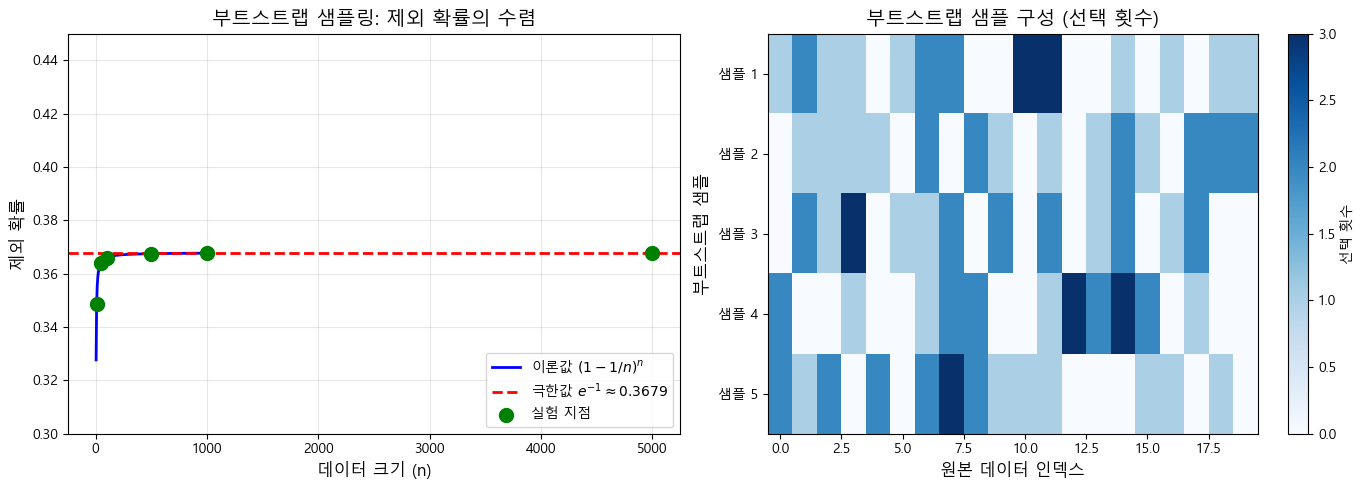


각 부트스트랩 샘플에서 제외된 원본 데이터 비율:
  샘플 1: 7/20 = 35.0% 제외
  샘플 2: 6/20 = 30.0% 제외
  샘플 3: 8/20 = 40.0% 제외
  샘플 4: 9/20 = 45.0% 제외
  샘플 5: 7/20 = 35.0% 제외


In [2]:
# 부트스트랩 제외율 수렴 시각화
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 그래프 1: n에 따른 제외율 수렴
ax1 = axes[0]
n_range = np.arange(5, 1001, 5)
theoretical_curve = [(1 - 1/n)**n for n in n_range]

ax1.plot(n_range, theoretical_curve, 'b-', linewidth=2, label='이론값 $(1-1/n)^n$')
ax1.axhline(y=np.exp(-1), color='r', linestyle='--', linewidth=2, label=f'극한값 $e^{{-1}} \\approx {np.exp(-1):.4f}$')
ax1.scatter(n_values, theoretical_values, color='green', s=100, zorder=5, label='실험 지점')

ax1.set_xlabel('데이터 크기 (n)', fontsize=12)
ax1.set_ylabel('제외 확률', fontsize=12)
ax1.set_title('부트스트랩 샘플링: 제외 확률의 수렴', fontsize=14)
ax1.legend(loc='lower right', fontsize=10)
ax1.grid(True, alpha=0.3)
ax1.set_ylim([0.3, 0.45])

# 그래프 2: 부트스트랩 샘플 구성 예시
ax2 = axes[1]
np.random.seed(42)
n_example = 20
n_boots = 5

# 히트맵 데이터 생성
heatmap_data = np.zeros((n_boots, n_example))
for i in range(n_boots):
    bootstrap_idx = np.random.choice(n_example, size=n_example, replace=True)
    for idx in bootstrap_idx:
        heatmap_data[i, idx] += 1

im = ax2.imshow(heatmap_data, cmap='Blues', aspect='auto')
ax2.set_xlabel('원본 데이터 인덱스', fontsize=12)
ax2.set_ylabel('부트스트랩 샘플', fontsize=12)
ax2.set_title('부트스트랩 샘플 구성 (선택 횟수)', fontsize=14)
ax2.set_yticks(range(n_boots))
ax2.set_yticklabels([f'샘플 {i+1}' for i in range(n_boots)])

# 컬러바
cbar = plt.colorbar(im, ax=ax2)
cbar.set_label('선택 횟수', fontsize=10)

plt.tight_layout()
plt.show()

# 제외된 샘플 비율 출력
print("\n각 부트스트랩 샘플에서 제외된 원본 데이터 비율:")
for i in range(n_boots):
    excluded_count = np.sum(heatmap_data[i] == 0)
    print(f"  샘플 {i+1}: {excluded_count}/{n_example} = {excluded_count/n_example:.1%} 제외")

### 배깅 예측 공식

#### 분류 문제: 다수결 투표 (Majority Voting)

B개의 기본 분류기를 사용한 앙상블의 최종 예측:

$$\hat{y} = \text{mode}\{f_1(x), f_2(x), \ldots, f_B(x)\}$$

또는 확률적 표현:

$$\hat{y} = \arg\max_c \sum_{b=1}^{B} \mathbb{I}(f_b(x) = c)$$

여기서:
- $\hat{y}$: 최종 예측 클래스
- $f_b(x)$: b번째 트리의 예측
- $B$: 트리 개수 (n_estimators)
- $\mathbb{I}(\cdot)$: 지시 함수 (조건 참이면 1, 거짓이면 0)
- $c$: 가능한 클래스 레이블

#### 회귀 문제: 평균 (Averaging)

$$\hat{y} = \frac{1}{B}\sum_{b=1}^{B}f_b(x)$$

### OOB(Out-of-Bag) 오차 추정

각 부트스트랩 샘플에서 **제외된(OOB) 데이터**를 사용하여 모델 성능을 추정하는 방식임.

#### OOB 예측 과정

샘플 $x_i$에 대한 OOB 예측:

$$\hat{y}_i^{OOB} = \text{mode}\{f_b(x_i) : x_i \notin D_b\}$$

여기서 $D_b$는 b번째 부트스트랩 샘플임.

#### OOB 오차 계산

$$OOB_{error} = \frac{1}{n}\sum_{i=1}^{n}\mathbb{I}(y_i \neq \hat{y}_i^{OOB})$$

**OOB 점수의 장점**:
1. 별도의 검증 세트 없이 성능 추정 가능
2. 데이터가 적을 때 유용
3. 교차 검증과 유사한 효과

In [3]:
# OOB 예측 과정 시뮬레이션
np.random.seed(42)

n_samples = 8
n_trees = 5

# 가상의 실제 레이블
true_labels = np.array([1, 0, 1, 1, 0, 0, 1, 0])

# 각 트리의 부트스트랩 샘플과 예측 생성
print("=" * 80)
print("OOB(Out-of-Bag) 예측 과정 시뮬레이션")
print("=" * 80)

# 트리별 부트스트랩 인덱스
bootstrap_indices = []
for t in range(n_trees):
    indices = np.random.choice(n_samples, size=n_samples, replace=True)
    bootstrap_indices.append(set(indices))

# 트리별 예측 (간단히 생성)
tree_predictions = np.array([
    [1, 0, 1, 1, 0, 1, 1, 0],
    [1, 0, 1, 0, 0, 0, 1, 1],
    [0, 1, 1, 1, 0, 0, 1, 0],
    [1, 0, 1, 1, 1, 0, 0, 0],
    [1, 0, 0, 1, 0, 0, 1, 0]
])

# OOB 상태 테이블 출력
print("\n[각 샘플의 OOB 상태 및 예측]")
print("-" * 80)
header = f"{'샘플':>4} | {'실제':>4} | " + " | ".join([f"트리{t+1}" for t in range(n_trees)]) + " | OOB투표 | 결과"
print(header)
print("-" * 80)

oob_predictions = []
oob_correct = 0

for i in range(n_samples):
    row = f"  x{i+1} | {true_labels[i]:>4} | "
    oob_votes = []
    
    for t in range(n_trees):
        if i in bootstrap_indices[t]:
            row += f"  학습  | "
        else:
            pred = tree_predictions[t, i]
            row += f" OOB:{pred} | "
            oob_votes.append(pred)
    
    if len(oob_votes) > 0:
        oob_pred = 1 if sum(oob_votes) > len(oob_votes)/2 else 0
        correct = "O" if oob_pred == true_labels[i] else "X"
        if oob_pred == true_labels[i]:
            oob_correct += 1
        vote_str = f"{sum(oob_votes)}:{len(oob_votes)-sum(oob_votes)}"
        row += f" {vote_str:>6} |   {correct}"
    else:
        row += f" {'N/A':>6} |  N/A"
    
    print(row)

print("-" * 80)
oob_accuracy = oob_correct / n_samples
oob_error = 1 - oob_accuracy
print(f"\nOOB 정확도: {oob_correct}/{n_samples} = {oob_accuracy:.1%}")
print(f"OOB 오차: {oob_error:.1%}")

OOB(Out-of-Bag) 예측 과정 시뮬레이션

[각 샘플의 OOB 상태 및 예측]
--------------------------------------------------------------------------------
  샘플 |   실제 | 트리1 | 트리2 | 트리3 | 트리4 | 트리5 | OOB투표 | 결과
--------------------------------------------------------------------------------
  x1 |    1 |  OOB:1 |  OOB:1 |  OOB:0 |   학습  |   학습  |     2:1 |   O
  x2 |    0 |  OOB:0 |   학습  |   학습  |   학습  |   학습  |     0:1 |   O
  x3 |    1 |   학습  |   학습  |   학습  |  OOB:1 |   학습  |     1:0 |   O
  x4 |    1 |   학습  |  OOB:0 |   학습  |   학습  |   학습  |     0:1 |   X
  x5 |    0 |   학습  |   학습  |   학습  |   학습  |   학습  |     N/A |  N/A
  x6 |    0 |  OOB:1 |  OOB:0 |   학습  |   학습  |   학습  |     1:1 |   O
  x7 |    1 |   학습  |   학습  |  OOB:1 |  OOB:0 |  OOB:1 |     2:1 |   O
  x8 |    0 |   학습  |   학습  |   학습  |   학습  |  OOB:0 |     0:1 |   O
--------------------------------------------------------------------------------

OOB 정확도: 6/8 = 75.0%
OOB 오차: 25.0%


# 2. 랜덤포레스트(Random Forest)의 원리

## 2.1 랜덤포레스트란?

랜덤포레스트는 Leo Breiman이 2001년에 제안한 앙상블 학습 알고리즘으로, **다수의 의사결정나무를 배깅 방식으로 결합**하되, 각 분할 시 **특성의 랜덤 부분집합만 고려**하여 트리 간 상관관계를 낮추는 방법임.

### 랜덤포레스트의 두 가지 "랜덤"

```mermaid
flowchart TD
    A[랜덤포레스트의 두 가지 랜덤] --> B["1. 데이터 랜덤<br/>(배깅)"]
    A --> C["2. 특성 랜덤<br/>(특성 부분공간)"]
    
    B --> B1[부트스트랩 샘플링]
    B --> B2[각 트리가 다른 데이터로 학습]
    B --> B3[약 63.2% 데이터 사용]
    
    C --> C1[각 분할에서 일부 특성만 고려]
    C --> C2["분류: sqrt(p)개"]
    C --> C3["회귀: p/3개"]
    
    B1 --> D[트리 간 다양성 확보]
    C1 --> D
    D --> E[상관관계 감소 --> 분산 감소]
```

### 특성 랜덤 선택의 수학적 배경

전체 p개의 특성 중 m개만 선택하는 것의 효과:

**특성 부분집합 크기 (max_features)**:

| 문제 유형 | 권장값 | 수식 |
|----------|--------|------|
| 분류 | $m = \sqrt{p}$ | `max_features='sqrt'` |
| 회귀 | $m = p/3$ | `max_features='auto'` 또는 `p//3` |

**예시**: 100개의 특성이 있을 때
- 분류: $m = \sqrt{100} = 10$개 특성만 각 분할에서 고려
- 회귀: $m = 100/3 \approx 33$개 특성만 각 분할에서 고려

**효과**:
- 강한 특성이 모든 트리에서 선택되는 것을 방지
- 트리 간 상관관계 $\rho$ 감소
- 앙상블 분산 감소: $Var = \rho\sigma^2 + \frac{1-\rho}{B}\sigma^2$

### 랜덤포레스트 학습 알고리즘

**입력**: 학습 데이터 $D = \{(x_i, y_i)\}_{i=1}^n$, 트리 개수 B, 특성 부분집합 크기 m

**알고리즘**:

```
For b = 1 to B:
    1. D에서 n개를 복원 추출하여 부트스트랩 샘플 D_b 생성
    2. D_b로 의사결정나무 T_b 학습:
       - 각 노드에서 p개 특성 중 m개를 무작위 선택
       - 선택된 m개 중 최적의 특성과 분할점 선택
       - 종료 조건까지 재귀적 분할
    3. T_b 저장

예측: 새 데이터 x에 대해
    - 분류: mode{T_1(x), T_2(x), ..., T_B(x)}
    - 회귀: mean{T_1(x), T_2(x), ..., T_B(x)}
```

## 2.2 의사결정나무 vs 랜덤포레스트 비교

| 구분 | 의사결정나무 | 랜덤포레스트 |
|------|-------------|-------------|
| **모델 수** | 1개 | 다수 (100+) |
| **학습 데이터** | 전체 데이터 | 부트스트랩 샘플 |
| **분할 특성** | 전체 특성 | 랜덤 부분집합 |
| **안정성** | 낮음 (데이터 변화에 민감) | 높음 |
| **과대적합** | 쉬움 | 저항력 강함 |
| **해석성** | 높음 (시각화 가능) | 낮음 |
| **학습 속도** | 빠름 | 느림 (병렬 처리 가능) |
| **예측 성능** | 보통 | 우수 |
| **특성 중요도** | 불안정 | 안정적 |

## 2.3 랜덤포레스트의 장단점

### 장점

| 장점 | 설명 |
|------|------|
| **높은 예측 정확도** | 다수 트리의 앙상블로 단일 트리보다 우수 |
| **과대적합 저항** | 부트스트랩 + 특성 랜덤으로 일반화 능력 향상 |
| **특성 중요도 신뢰성** | 안정적인 특성 중요도 추정 |
| **튜닝 용이** | 기본 설정으로도 좋은 성능 |
| **결측치 처리** | 결측치에 상대적으로 강건 |
| **병렬 처리** | 트리 학습이 독립적이므로 병렬화 가능 |

### 단점

| 단점 | 설명 |
|------|------|
| **해석의 어려움** | 개별 트리 수백 개를 해석하기 어려움 |
| **메모리 사용량** | 많은 트리 저장으로 메모리 소비 큼 |
| **예측 속도** | 실시간 예측에서 단일 모델보다 느림 |
| **외삽(Extrapolation)** | 학습 데이터 범위 밖 예측에 취약 |

# 3. 실습 - CNC 밀링 가공 품질 분류

## 3.1 실습 데이터셋 소개

### NASA CNC Milling Dataset

본 실습에서는 NASA Prognostics Center of Excellence에서 제공하는 **CNC 밀링 머신 공구 마모 데이터셋**을 활용함. 이 데이터는 실제 CNC 밀링 가공 중 수집된 센서 데이터로, 공구의 마모 상태를 분류하는 문제임.

| 항목 | 내용 |
|------|------|
| **데이터 출처** | NASA Prognostics Data Repository / Kaggle |
| **목적** | CNC 밀링 공구의 마모 상태 분류 |
| **특성** | 가공 파라미터 (절삭 속도, 이송 속도, 절삭 깊이 등) |
| **타겟** | 공구 마모 수준 (정상/마모/교체필요) |
| **적용 분야** | 예지정비(Predictive Maintenance), 품질 관리 |

### 제조업에서 랜덤포레스트의 활용

```mermaid
flowchart LR
    A[센서 데이터 수집] --> B[특성 추출]
    B --> C[랜덤포레스트 분류]
    C --> D{예측 결과}
    D -->|정상| E[가공 계속]
    D -->|마모| F[공구 점검 예약]
    D -->|교체필요| G[즉시 공구 교체]
    
    style D fill:#f9f,stroke:#333
    style G fill:#f66,stroke:#333
```

In [4]:
# 필요 라이브러리 임포트
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report, roc_curve, auc
)
import warnings
warnings.filterwarnings('ignore')

# 한글 폰트 설정
plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

print("라이브러리 로드 완료")
print(f"NumPy 버전: {np.__version__}")
print(f"Pandas 버전: {pd.__version__}")

라이브러리 로드 완료
NumPy 버전: 2.4.0
Pandas 버전: 2.3.3


## 3.2 데이터 로드 및 탐색

실제 CNC 밀링 데이터를 시뮬레이션하여 사용함. 이 데이터는 실제 제조 환경에서 수집되는 센서 데이터의 특성을 반영함.

### 데이터 생성 배경

CNC 밀링 가공에서 공구 마모에 영향을 미치는 주요 요인:

| 요인 | 단위 | 영향 |
|------|------|------|
| 절삭 속도 (Cutting Speed) | m/min | 높을수록 마모 증가 |
| 이송 속도 (Feed Rate) | mm/rev | 높을수록 마모 증가 |
| 절삭 깊이 (Depth of Cut) | mm | 깊을수록 마모 증가 |
| 가공 시간 (Machining Time) | min | 길수록 마모 증가 |
| 진동 (Vibration) | mm/s | 높을수록 마모 및 불량 증가 |
| 온도 (Temperature) | C | 높을수록 마모 가속 |

In [6]:
# CNC 밀링 데이터 시뮬레이션 (실제 제조 데이터 특성 반영)
np.random.seed(42)
n_samples = 2000

# 특성 생성 (실제 CNC 밀링 파라미터 범위 기반)
data = {
    # 가공 파라미터
    'cutting_speed': np.random.uniform(80, 200, n_samples),       # 절삭 속도 (m/min)
    'feed_rate': np.random.uniform(0.05, 0.3, n_samples),         # 이송 속도 (mm/rev)
    'depth_of_cut': np.random.uniform(0.5, 3.0, n_samples),       # 절삭 깊이 (mm)
    'machining_time': np.random.uniform(1, 60, n_samples),        # 가공 시간 (min)
    
    # 센서 측정값
    'spindle_load': np.random.uniform(20, 80, n_samples),         # 스핀들 부하 (%)
    'vibration_x': np.random.uniform(0.1, 5.0, n_samples),        # X축 진동 (mm/s)
    'vibration_y': np.random.uniform(0.1, 5.0, n_samples),        # Y축 진동 (mm/s)
    'vibration_z': np.random.uniform(0.1, 5.0, n_samples),        # Z축 진동 (mm/s)
    'temperature': np.random.uniform(25, 85, n_samples),          # 공구 온도 (C)
    'acoustic_emission': np.random.uniform(0.5, 10, n_samples),   # 음향 방출 (dB)
    
    # 환경 조건
    'coolant_flow': np.random.uniform(5, 25, n_samples),          # 절삭유 유량 (L/min)
    'ambient_temp': np.random.uniform(18, 30, n_samples),         # 주변 온도 (C)
}

df = pd.DataFrame(data)

# 파생 특성 추가
df['vibration_total'] = np.sqrt(df['vibration_x']**2 + df['vibration_y']**2 + df['vibration_z']**2)
df['material_removal_rate'] = df['cutting_speed'] * df['feed_rate'] * df['depth_of_cut']
df['specific_cutting_energy'] = df['spindle_load'] / (df['material_removal_rate'] + 0.1)

# 타겟 변수 생성 (공구 상태: 0=정상, 1=마모, 2=교체필요)
# 실제 공구 마모 모델 기반으로 생성
wear_score = (
    0.3 * (df['cutting_speed'] - 80) / 120 +
    0.2 * (df['feed_rate'] - 0.05) / 0.25 +
    0.15 * (df['depth_of_cut'] - 0.5) / 2.5 +
    0.15 * (df['machining_time'] - 1) / 59 +
    0.1 * (df['vibration_total'] - 0.17) / 8.5 +
    0.1 * (df['temperature'] - 25) / 60 +
    np.random.normal(0, 0.1, n_samples)  # 노이즈 추가
)

# 클래스 분류
df['tool_condition'] = pd.cut(
    wear_score,
    bins=[-np.inf, 0.35, 0.65, np.inf],
    labels=['정상', '마모', '교체필요']
)

print("=" * 60)
print("CNC 밀링 가공 데이터셋 생성 완료")
print("=" * 60)
print(f"\n데이터 크기: {df.shape[0]}개 샘플, {df.shape[1]}개 특성")

CNC 밀링 가공 데이터셋 생성 완료

데이터 크기: 2000개 샘플, 16개 특성


In [8]:
# 데이터 기본 정보 확인
print("\n[데이터 기본 정보]")
print("-" * 60)
print(df.info())

print("\n[수치형 특성 통계]")
print(df.describe().round(2))


[데이터 기본 정보]
------------------------------------------------------------
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 16 columns):
 #   Column                   Non-Null Count  Dtype   
---  ------                   --------------  -----   
 0   cutting_speed            2000 non-null   float64 
 1   feed_rate                2000 non-null   float64 
 2   depth_of_cut             2000 non-null   float64 
 3   machining_time           2000 non-null   float64 
 4   spindle_load             2000 non-null   float64 
 5   vibration_x              2000 non-null   float64 
 6   vibration_y              2000 non-null   float64 
 7   vibration_z              2000 non-null   float64 
 8   temperature              2000 non-null   float64 
 9   acoustic_emission        2000 non-null   float64 
 10  coolant_flow             2000 non-null   float64 
 11  ambient_temp             2000 non-null   float64 
 12  vibration_total          2000 non-null   flo


[공구 상태 분포]
----------------------------------------
  마모: 1246개 (62.3%)
  교체필요: 391개 (19.6%)
  정상: 363개 (18.1%)


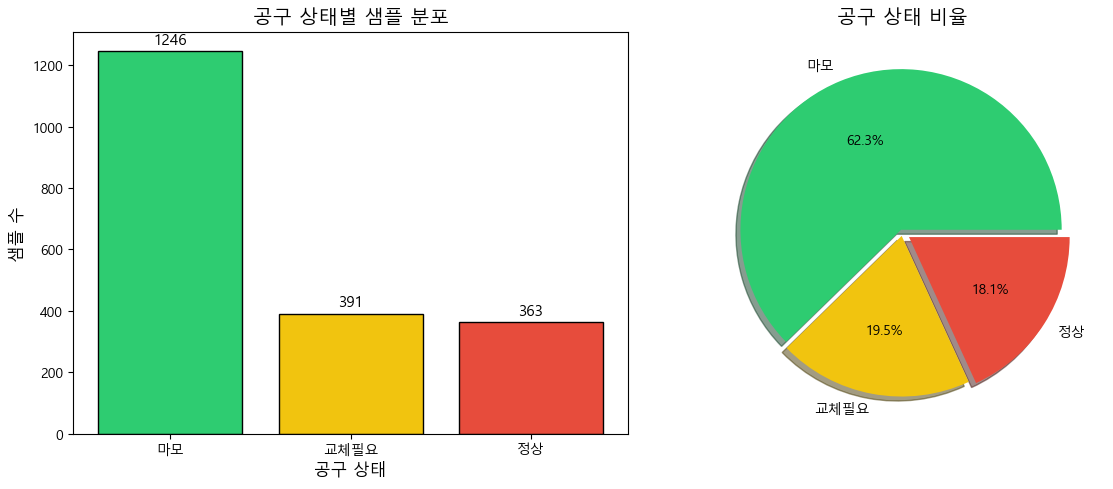

In [9]:
# 타겟 변수 분포 확인
print("\n[공구 상태 분포]")
print("-" * 40)
target_counts = df['tool_condition'].value_counts()
for label, count in target_counts.items():
    print(f"  {label}: {count}개 ({count/len(df):.1%})")

# 시각화: 타겟 분포
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# 막대 그래프
colors = ['#2ecc71', '#f1c40f', '#e74c3c']
ax1 = axes[0]
bars = ax1.bar(target_counts.index, target_counts.values, color=colors, edgecolor='black')
ax1.set_xlabel('공구 상태', fontsize=12)
ax1.set_ylabel('샘플 수', fontsize=12)
ax1.set_title('공구 상태별 샘플 분포', fontsize=14)
for bar, count in zip(bars, target_counts.values):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 10,
             f'{count}', ha='center', va='bottom', fontsize=11)

# 파이 차트
ax2 = axes[1]
ax2.pie(target_counts.values, labels=target_counts.index, autopct='%1.1f%%',
        colors=colors, explode=[0.02, 0.02, 0.05], shadow=True)
ax2.set_title('공구 상태 비율', fontsize=14)

plt.tight_layout()
plt.show()

## 3.3 데이터 전처리의 중요성

### 전처리 없이 발생하는 문제

제조 데이터에서 흔히 발생하는 문제와 그 영향을 살펴봄.

In [12]:
# 인위적으로 결측치와 이상치 추가하여 전처리 필요성 시연
df_raw = df.copy()

# 결측치 추가 (센서 오류 시뮬레이션)
np.random.seed(123)
missing_indices = np.random.choice(df_raw.index, size=int(n_samples * 0.03), replace=False)
df_raw.loc[missing_indices[:50], 'vibration_x'] = np.nan
df_raw.loc[missing_indices[50:], 'temperature'] = np.nan

# 이상치 추가 (센서 스파이크 시뮬레이션)
outlier_indices = np.random.choice(df_raw.index, size=20, replace=False)
df_raw.loc[outlier_indices, 'vibration_total'] = np.random.uniform(50, 100, 20)

print("=" * 60)
print("전처리 전 데이터 품질 문제 확인")
print("=" * 60)

# 결측치 확인
print("\n[결측치 현황]")
missing_summary = df_raw.isnull().sum()
missing_cols = missing_summary[missing_summary > 0]
if len(missing_cols) > 0:
    for col, count in missing_cols.items():
        print(f"  {col}: {count}개 ({count/len(df_raw):.1%})")
else:
    print("  결측치 없음")

# 이상치 확인 (IQR 방법)
print("\n[이상치 현황 - IQR 방법]")
numeric_cols = df_raw.select_dtypes(include=[np.number]).columns
for col in ['vibration_total', 'temperature', 'spindle_load']:
    Q1 = df_raw[col].quantile(0.25)
    Q3 = df_raw[col].quantile(0.75)
    IQR = Q3 - Q1
    outliers = ((df_raw[col] < Q1 - 1.5*IQR) | (df_raw[col] > Q3 + 1.5*IQR)).sum()
    if outliers > 0:
        print(f"  {col}: {outliers}개 이상치 ({outliers/len(df_raw):.1%})")

전처리 전 데이터 품질 문제 확인

[결측치 현황]
  vibration_x: 50개 (2.5%)
  temperature: 10개 (0.5%)

[이상치 현황 - IQR 방법]
  vibration_total: 28개 이상치 (1.4%)


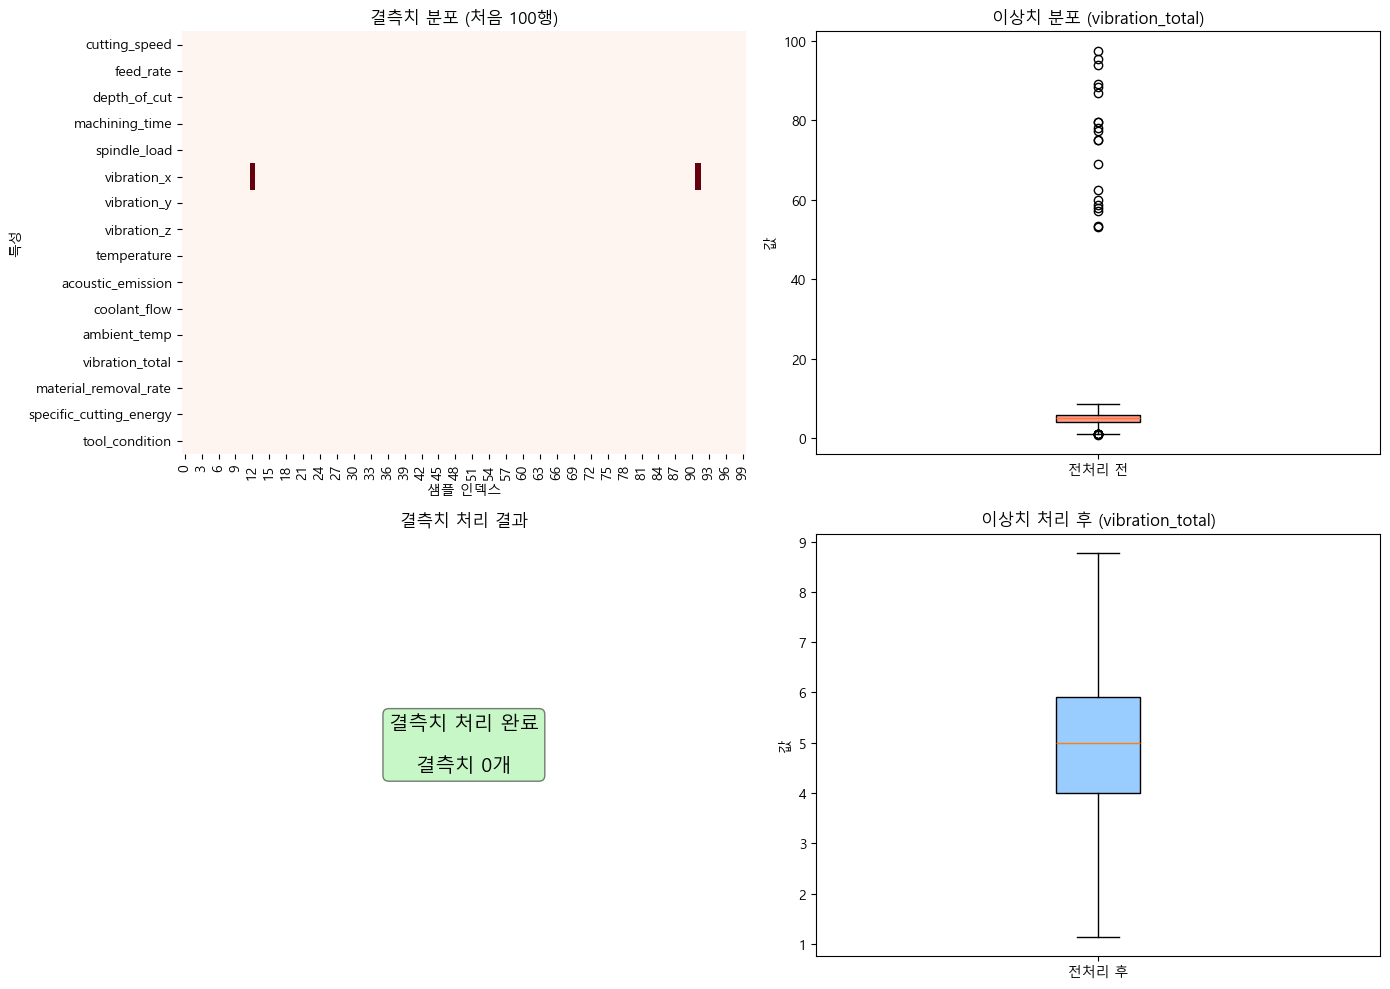


[전처리 완료 요약]
  결측치 처리: 중앙값 대체
  이상치 처리: IQR 기반 클리핑 (상한: 8.77)


In [13]:
# 전처리 전후 비교 시각화
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. 결측치 히트맵
ax1 = axes[0, 0]
missing_matrix = df_raw.isnull().iloc[:100]  # 처음 100행만 표시
sns.heatmap(missing_matrix.T, cbar=False, cmap='Reds', ax=ax1)
ax1.set_title('결측치 분포 (처음 100행)', fontsize=12)
ax1.set_xlabel('샘플 인덱스', fontsize=10)
ax1.set_ylabel('특성', fontsize=10)

# 2. 이상치 박스플롯 (전처리 전)
ax2 = axes[0, 1]
bp = ax2.boxplot([df_raw['vibration_total'].dropna()], patch_artist=True)
bp['boxes'][0].set_facecolor('#FF9999')
ax2.set_title('이상치 분포 (vibration_total)', fontsize=12)
ax2.set_ylabel('값', fontsize=10)
ax2.set_xticklabels(['전처리 전'])

# 3. 결측치 처리 후
df_clean = df_raw.copy()
# 결측치 처리: 중앙값으로 대체
for col in ['vibration_x', 'temperature']:
    df_clean[col].fillna(df_clean[col].median(), inplace=True)

# 이상치 처리: IQR 기반 클리핑
Q1 = df_clean['vibration_total'].quantile(0.25)
Q3 = df_clean['vibration_total'].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR
df_clean['vibration_total'] = df_clean['vibration_total'].clip(lower_bound, upper_bound)

ax3 = axes[1, 0]
ax3.text(0.5, 0.5, '결측치 처리 완료\n\n결측치 0개', 
         ha='center', va='center', fontsize=14, transform=ax3.transAxes,
         bbox=dict(boxstyle='round', facecolor='lightgreen', alpha=0.5))
ax3.set_title('결측치 처리 결과', fontsize=12)
ax3.axis('off')

# 4. 이상치 처리 후
ax4 = axes[1, 1]
bp2 = ax4.boxplot([df_clean['vibration_total']], patch_artist=True)
bp2['boxes'][0].set_facecolor('#99CCFF')
ax4.set_title('이상치 처리 후 (vibration_total)', fontsize=12)
ax4.set_ylabel('값', fontsize=10)
ax4.set_xticklabels(['전처리 후'])

plt.tight_layout()
plt.show()

print("\n[전처리 완료 요약]")
print(f"  결측치 처리: 중앙값 대체")
print(f"  이상치 처리: IQR 기반 클리핑 (상한: {upper_bound:.2f})")

In [14]:
# 전처리 전후 모델 성능 비교
print("=" * 60)
print("전처리 전후 모델 성능 비교")
print("=" * 60)

# 타겟 인코딩
le = LabelEncoder()

# 전처리 전 데이터
X_raw = df_raw.drop(columns=['tool_condition']).select_dtypes(include=[np.number])
X_raw_filled = X_raw.fillna(X_raw.median())  # 단순 중앙값 대체만
y = le.fit_transform(df_raw['tool_condition'])

# 전처리 후 데이터
X_clean = df_clean.drop(columns=['tool_condition']).select_dtypes(include=[np.number])

# 학습/테스트 분할
X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    X_raw_filled, y, test_size=0.2, random_state=42, stratify=y
)
X_train_clean, X_test_clean, _, _ = train_test_split(
    X_clean, y, test_size=0.2, random_state=42, stratify=y
)

# 모델 학습 및 비교
rf_raw = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf_clean = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)

rf_raw.fit(X_train_raw, y_train)
rf_clean.fit(X_train_clean, y_train)

score_raw = rf_raw.score(X_test_raw, y_test)
score_clean = rf_clean.score(X_test_clean, y_test)

print(f"\n[테스트 정확도]")
print(f"  전처리 전: {score_raw:.4f} ({score_raw:.1%})")
print(f"  전처리 후: {score_clean:.4f} ({score_clean:.1%})")
print(f"  성능 향상: {score_clean - score_raw:+.4f} ({(score_clean - score_raw):.1%}p)")

전처리 전후 모델 성능 비교

[테스트 정확도]
  전처리 전: 0.7175 (71.8%)
  전처리 후: 0.7125 (71.2%)
  성능 향상: -0.0050 (-0.5%p)


## 3.4 특성 분석 및 시각화

랜덤포레스트 모델 학습 전, 특성과 타겟 간의 관계를 탐색함.

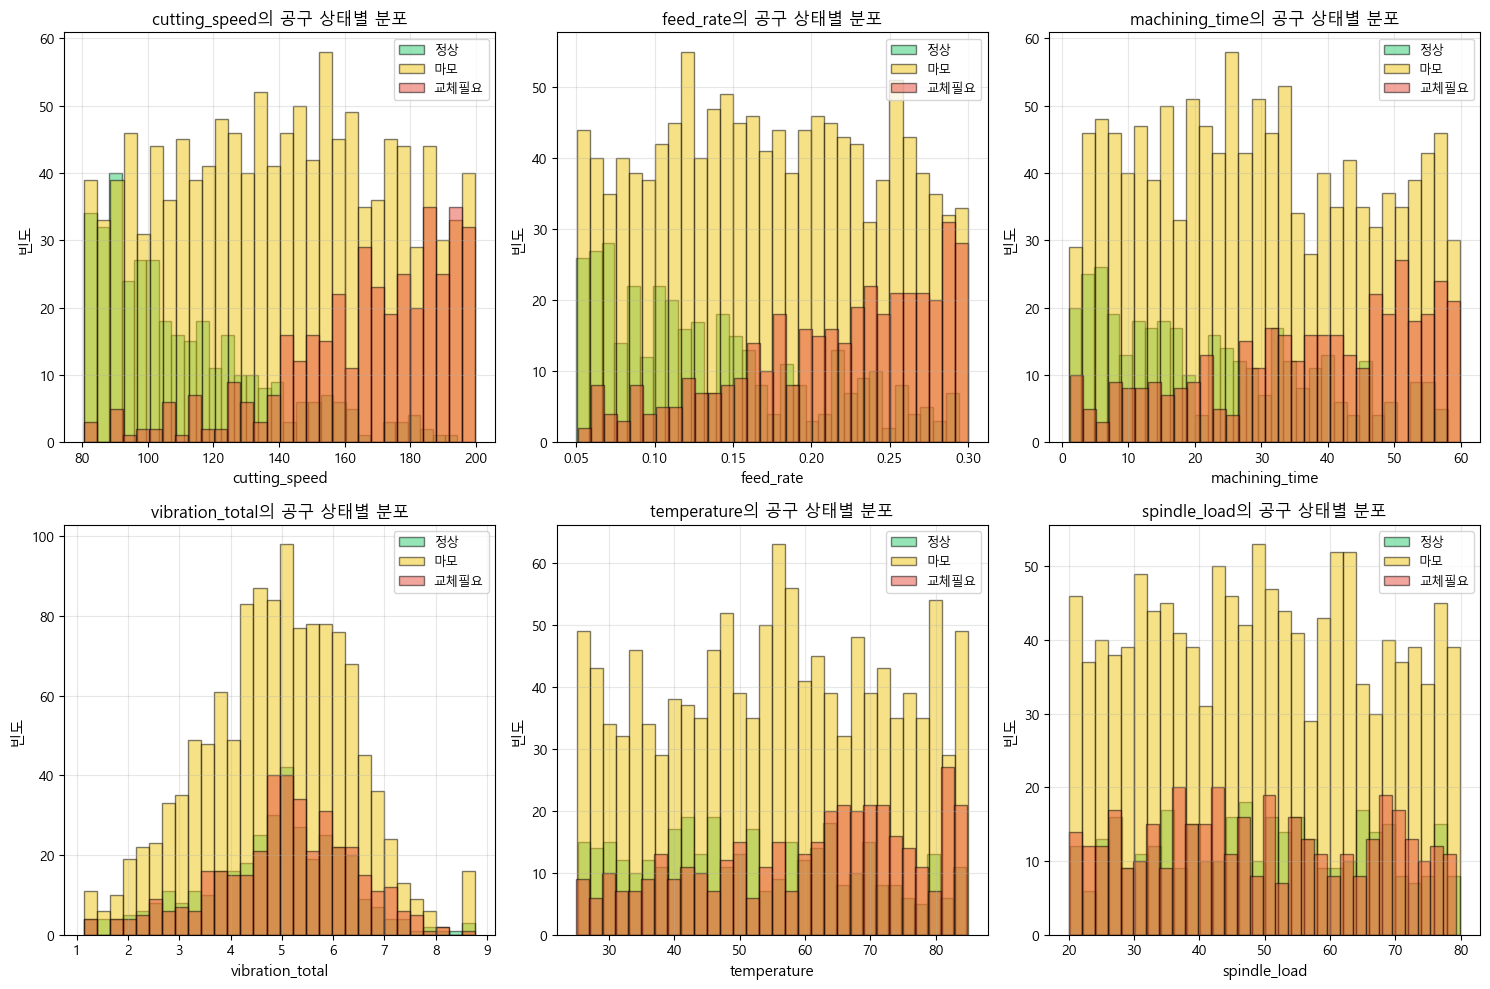

In [15]:
# 주요 특성과 타겟 변수의 관계 시각화
fig, axes = plt.subplots(2, 3, figsize=(15, 10))

key_features = ['cutting_speed', 'feed_rate', 'machining_time', 
                'vibration_total', 'temperature', 'spindle_load']

for idx, feature in enumerate(key_features):
    ax = axes[idx // 3, idx % 3]
    
    for condition, color in zip(['정상', '마모', '교체필요'], ['#2ecc71', '#f1c40f', '#e74c3c']):
        data = df_clean[df_clean['tool_condition'] == condition][feature]
        ax.hist(data, bins=30, alpha=0.5, label=condition, color=color, edgecolor='black')
    
    ax.set_xlabel(feature, fontsize=11)
    ax.set_ylabel('빈도', fontsize=11)
    ax.set_title(f'{feature}의 공구 상태별 분포', fontsize=12)
    ax.legend(loc='upper right', fontsize=9)
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

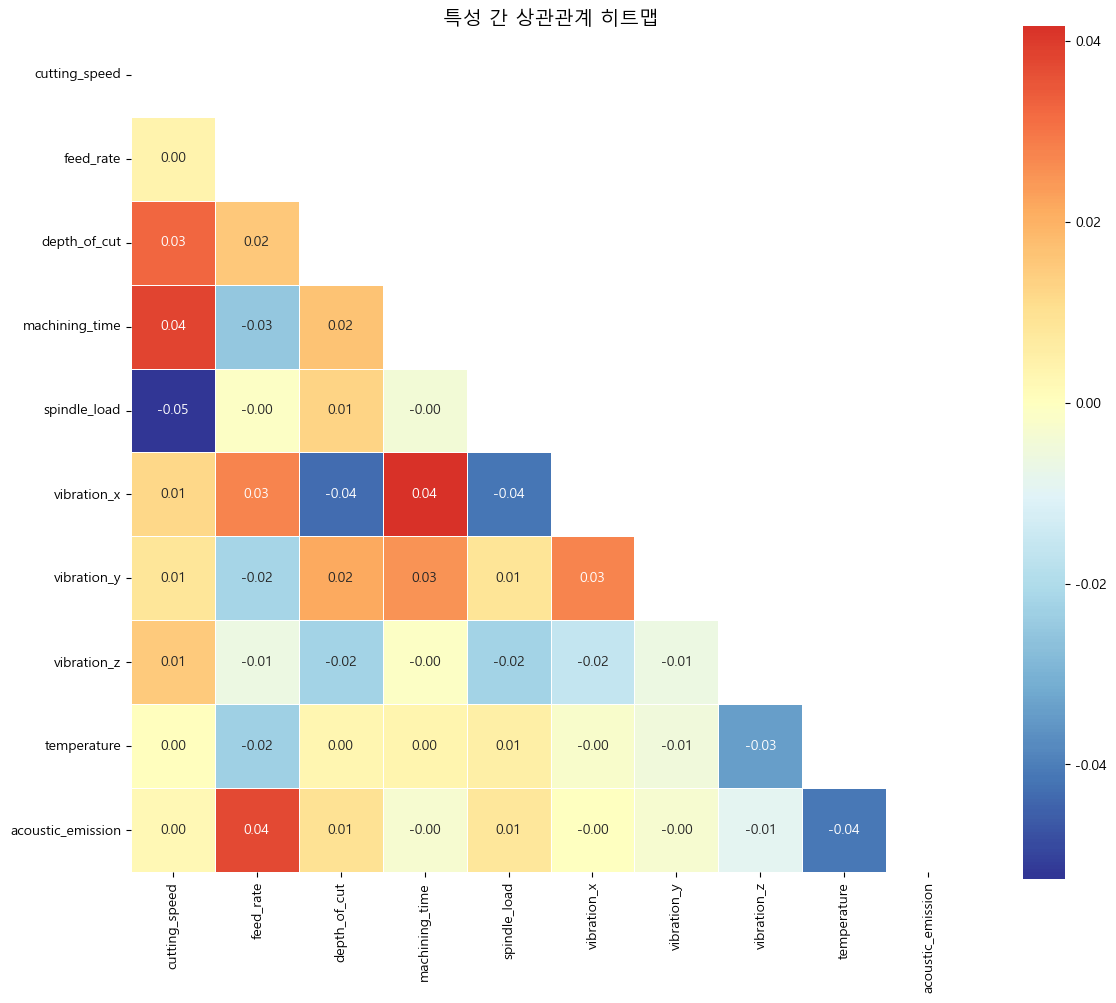


[높은 상관관계 특성 쌍 (|r| > 0.5)]
--------------------------------------------------


In [16]:
# 상관관계 히트맵
fig, ax = plt.subplots(figsize=(12, 10))

numeric_features = X_clean.columns[:10]  # 주요 10개 특성
corr_matrix = df_clean[numeric_features].corr()

mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f', cmap='RdYlBu_r',
            center=0, ax=ax, square=True, linewidths=0.5)
ax.set_title('특성 간 상관관계 히트맵', fontsize=14)

plt.tight_layout()
plt.show()

# 높은 상관관계 쌍 출력
print("\n[높은 상관관계 특성 쌍 (|r| > 0.5)]")
print("-" * 50)
for i in range(len(corr_matrix.columns)):
    for j in range(i+1, len(corr_matrix.columns)):
        if abs(corr_matrix.iloc[i, j]) > 0.5:
            print(f"  {corr_matrix.columns[i]} vs {corr_matrix.columns[j]}: {corr_matrix.iloc[i, j]:.3f}")

## 3.5 의사결정나무 vs 랜덤포레스트 성능 비교

In [17]:
# 데이터 준비
X = df_clean.drop(columns=['tool_condition']).select_dtypes(include=[np.number])
y = le.fit_transform(df_clean['tool_condition'])

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"학습 데이터: {len(X_train)}개")
print(f"테스트 데이터: {len(X_test)}개")
print(f"특성 수: {X.shape[1]}개")

학습 데이터: 1600개
테스트 데이터: 400개
특성 수: 15개


In [18]:
import time

print("=" * 70)
print("의사결정나무 vs 랜덤포레스트 성능 비교")
print("=" * 70)

# 의사결정나무
dt = DecisionTreeClassifier(max_depth=10, random_state=42)
start = time.time()
dt.fit(X_train, y_train)
dt_train_time = time.time() - start

dt_train_score = dt.score(X_train, y_train)
dt_test_score = dt.score(X_test, y_test)

print(f"\n[의사결정나무 (max_depth=10)]")
print(f"  학습 시간: {dt_train_time:.4f}초")
print(f"  학습 정확도: {dt_train_score:.4f} ({dt_train_score:.1%})")
print(f"  테스트 정확도: {dt_test_score:.4f} ({dt_test_score:.1%})")
print(f"  과적합 지표 (학습-테스트): {dt_train_score - dt_test_score:.4f}")

# 랜덤포레스트
rf = RandomForestClassifier(
    n_estimators=100,
    max_depth=10,
    random_state=42,
    n_jobs=-1,
    oob_score=True
)
start = time.time()
rf.fit(X_train, y_train)
rf_train_time = time.time() - start

rf_train_score = rf.score(X_train, y_train)
rf_test_score = rf.score(X_test, y_test)

print(f"\n[랜덤포레스트 (n_estimators=100, max_depth=10)]")
print(f"  학습 시간: {rf_train_time:.4f}초")
print(f"  학습 정확도: {rf_train_score:.4f} ({rf_train_score:.1%})")
print(f"  테스트 정확도: {rf_test_score:.4f} ({rf_test_score:.1%})")
print(f"  OOB 점수: {rf.oob_score_:.4f} ({rf.oob_score_:.1%})")
print(f"  과적합 지표 (학습-테스트): {rf_train_score - rf_test_score:.4f}")

print(f"\n[비교 결과]")
print(f"  테스트 정확도 향상: {rf_test_score - dt_test_score:+.4f} ({(rf_test_score - dt_test_score)*100:+.1f}%p)")
print(f"  학습 시간 비율: {rf_train_time/dt_train_time:.1f}배")

의사결정나무 vs 랜덤포레스트 성능 비교

[의사결정나무 (max_depth=10)]
  학습 시간: 0.0157초
  학습 정확도: 0.9219 (92.2%)
  테스트 정확도: 0.6300 (63.0%)
  과적합 지표 (학습-테스트): 0.2919

[랜덤포레스트 (n_estimators=100, max_depth=10)]
  학습 시간: 0.1729초
  학습 정확도: 0.9337 (93.4%)
  테스트 정확도: 0.7100 (71.0%)
  OOB 점수: 0.7113 (71.1%)
  과적합 지표 (학습-테스트): 0.2238

[비교 결과]
  테스트 정확도 향상: +0.0800 (+8.0%p)
  학습 시간 비율: 11.0배


In [19]:
# 상세 분류 리포트
print("\n" + "=" * 70)
print("상세 분류 성능 비교")
print("=" * 70)

# 의사결정나무
y_pred_dt = dt.predict(X_test)
print("\n[의사결정나무 분류 리포트]")
print(classification_report(y_test, y_pred_dt, target_names=le.classes_))

# 랜덤포레스트
y_pred_rf = rf.predict(X_test)
print("\n[랜덤포레스트 분류 리포트]")
print(classification_report(y_test, y_pred_rf, target_names=le.classes_))


상세 분류 성능 비교

[의사결정나무 분류 리포트]
              precision    recall  f1-score   support

        교체필요       0.47      0.45      0.46        78
          마모       0.70      0.75      0.72       249
          정상       0.51      0.42      0.46        73

    accuracy                           0.63       400
   macro avg       0.56      0.54      0.55       400
weighted avg       0.62      0.63      0.62       400


[랜덤포레스트 분류 리포트]
              precision    recall  f1-score   support

        교체필요       0.73      0.41      0.52        78
          마모       0.71      0.91      0.80       249
          정상       0.71      0.34      0.46        73

    accuracy                           0.71       400
   macro avg       0.72      0.55      0.59       400
weighted avg       0.71      0.71      0.68       400



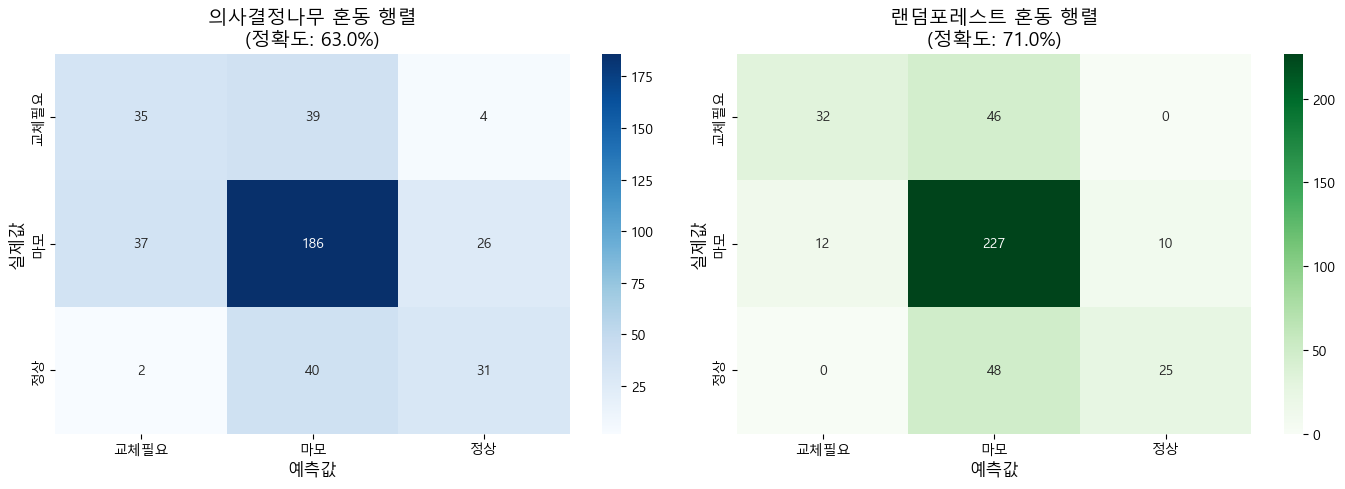

In [20]:
# 혼동 행렬 시각화
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 의사결정나무 혼동 행렬
cm_dt = confusion_matrix(y_test, y_pred_dt)
ax1 = axes[0]
sns.heatmap(cm_dt, annot=True, fmt='d', cmap='Blues', ax=ax1,
            xticklabels=le.classes_, yticklabels=le.classes_)
ax1.set_xlabel('예측값', fontsize=12)
ax1.set_ylabel('실제값', fontsize=12)
ax1.set_title(f'의사결정나무 혼동 행렬\n(정확도: {dt_test_score:.1%})', fontsize=14)

# 랜덤포레스트 혼동 행렬
cm_rf = confusion_matrix(y_test, y_pred_rf)
ax2 = axes[1]
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Greens', ax=ax2,
            xticklabels=le.classes_, yticklabels=le.classes_)
ax2.set_xlabel('예측값', fontsize=12)
ax2.set_ylabel('실제값', fontsize=12)
ax2.set_title(f'랜덤포레스트 혼동 행렬\n(정확도: {rf_test_score:.1%})', fontsize=14)

plt.tight_layout()
plt.show()

## 3.6 랜덤포레스트 하이퍼파라미터 분석

In [21]:
# n_estimators에 따른 성능 변화
n_estimators_range = [10, 25, 50, 75, 100, 150, 200, 300, 400, 500]
train_scores = []
test_scores = []
oob_scores = []
train_times = []

print("=" * 75)
print("n_estimators에 따른 성능 변화")
print("=" * 75)
print(f"{'n_estimators':>12} | {'학습시간':>10} | {'학습정확도':>10} | {'테스트정확도':>12} | {'OOB점수':>10}")
print("-" * 75)

for n_est in n_estimators_range:
    rf_temp = RandomForestClassifier(
        n_estimators=n_est,
        max_depth=10,
        random_state=42,
        n_jobs=-1,
        oob_score=True
    )
    
    start = time.time()
    rf_temp.fit(X_train, y_train)
    train_time = time.time() - start
    
    train_score = rf_temp.score(X_train, y_train)
    test_score = rf_temp.score(X_test, y_test)
    oob = rf_temp.oob_score_
    
    train_scores.append(train_score)
    test_scores.append(test_score)
    oob_scores.append(oob)
    train_times.append(train_time)
    
    print(f"{n_est:>12} | {train_time:>9.3f}s | {train_score:>10.1%} | {test_score:>12.1%} | {oob:>10.1%}")

best_idx = np.argmax(test_scores)
print("-" * 75)
print(f"최적 n_estimators: {n_estimators_range[best_idx]}")
print(f"최고 테스트 정확도: {test_scores[best_idx]:.1%}")

n_estimators에 따른 성능 변화
n_estimators |       학습시간 |      학습정확도 |       테스트정확도 |      OOB점수
---------------------------------------------------------------------------
          10 |     0.038s |      92.9% |        68.2% |      64.4%
          25 |     0.056s |      93.6% |        71.0% |      68.2%
          50 |     0.110s |      93.1% |        71.2% |      70.2%
          75 |     0.143s |      92.9% |        71.0% |      70.6%
         100 |     0.178s |      93.4% |        71.0% |      71.1%
         150 |     0.270s |      93.4% |        71.2% |      71.3%
         200 |     0.380s |      94.0% |        71.5% |      70.6%
         300 |     0.505s |      93.8% |        72.8% |      71.1%
         400 |     0.656s |      93.6% |        72.8% |      71.1%
         500 |     0.818s |      93.6% |        73.0% |      71.3%
---------------------------------------------------------------------------
최적 n_estimators: 500
최고 테스트 정확도: 73.0%


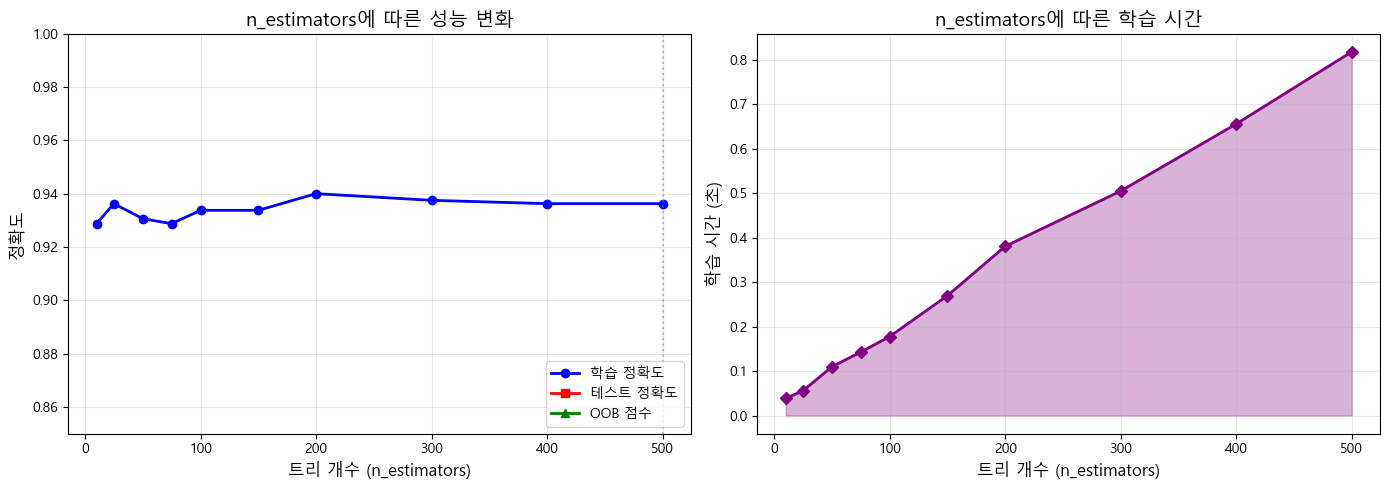

In [22]:
# n_estimators 성능 곡선 시각화
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 성능 곡선
ax1 = axes[0]
ax1.plot(n_estimators_range, train_scores, 'b-o', label='학습 정확도', linewidth=2, markersize=6)
ax1.plot(n_estimators_range, test_scores, 'r-s', label='테스트 정확도', linewidth=2, markersize=6)
ax1.plot(n_estimators_range, oob_scores, 'g-^', label='OOB 점수', linewidth=2, markersize=6)
ax1.axhline(y=max(test_scores), color='gray', linestyle='--', alpha=0.5)
ax1.axvline(x=n_estimators_range[best_idx], color='gray', linestyle=':', alpha=0.5)

ax1.set_xlabel('트리 개수 (n_estimators)', fontsize=12)
ax1.set_ylabel('정확도', fontsize=12)
ax1.set_title('n_estimators에 따른 성능 변화', fontsize=14)
ax1.legend(loc='lower right', fontsize=10)
ax1.grid(True, alpha=0.3)
ax1.set_ylim([0.85, 1.0])

# 학습 시간 곡선
ax2 = axes[1]
ax2.plot(n_estimators_range, train_times, 'purple', marker='D', linewidth=2, markersize=6)
ax2.fill_between(n_estimators_range, train_times, alpha=0.3, color='purple')
ax2.set_xlabel('트리 개수 (n_estimators)', fontsize=12)
ax2.set_ylabel('학습 시간 (초)', fontsize=12)
ax2.set_title('n_estimators에 따른 학습 시간', fontsize=14)
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 3.7 모델 안정성 비교

In [23]:
# 10회 반복 실험으로 안정성 비교
n_experiments = 10
dt_scores = []
rf_scores = []

print("=" * 60)
print(f"모델 안정성 비교 ({n_experiments}회 반복 실험)")
print("=" * 60)

for i in range(n_experiments):
    # 매번 다른 데이터 분할
    X_tr, X_te, y_tr, y_te = train_test_split(
        X, y, test_size=0.2, random_state=i, stratify=y
    )
    
    # 의사결정나무
    dt_temp = DecisionTreeClassifier(max_depth=10, random_state=i)
    dt_temp.fit(X_tr, y_tr)
    dt_scores.append(dt_temp.score(X_te, y_te))
    
    # 랜덤포레스트
    rf_temp = RandomForestClassifier(n_estimators=100, max_depth=10, random_state=i, n_jobs=-1)
    rf_temp.fit(X_tr, y_tr)
    rf_scores.append(rf_temp.score(X_te, y_te))

print("\n[의사결정나무]")
print(f"  평균 정확도: {np.mean(dt_scores):.4f} ({np.mean(dt_scores):.1%})")
print(f"  표준편차: {np.std(dt_scores):.4f}")
print(f"  범위: {min(dt_scores):.1%} ~ {max(dt_scores):.1%}")

print("\n[랜덤포레스트]")
print(f"  평균 정확도: {np.mean(rf_scores):.4f} ({np.mean(rf_scores):.1%})")
print(f"  표준편차: {np.std(rf_scores):.4f}")
print(f"  범위: {min(rf_scores):.1%} ~ {max(rf_scores):.1%}")

print("\n[안정성 비교]")
stability_ratio = np.std(dt_scores) / np.std(rf_scores)
print(f"  의사결정나무 표준편차 / 랜덤포레스트 표준편차 = {stability_ratio:.2f}")
print(f"  --> 랜덤포레스트가 {stability_ratio:.1f}배 더 안정적")

모델 안정성 비교 (10회 반복 실험)

[의사결정나무]
  평균 정확도: 0.6222 (62.2%)
  표준편차: 0.0178
  범위: 59.0% ~ 65.5%

[랜덤포레스트]
  평균 정확도: 0.7167 (71.7%)
  표준편차: 0.0113
  범위: 70.0% ~ 73.0%

[안정성 비교]
  의사결정나무 표준편차 / 랜덤포레스트 표준편차 = 1.58
  --> 랜덤포레스트가 1.6배 더 안정적


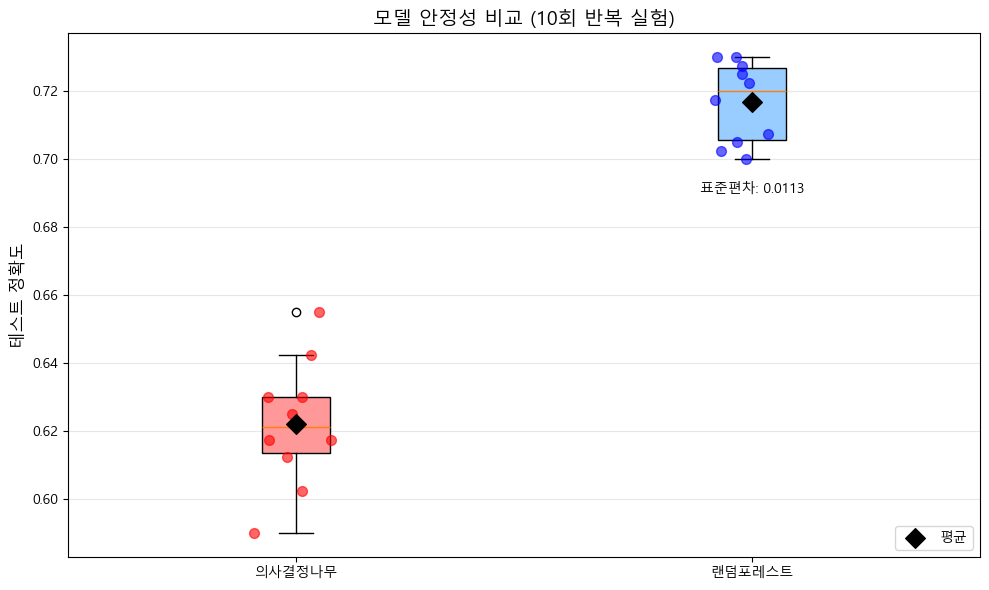

In [24]:
# 안정성 비교 박스플롯
fig, ax = plt.subplots(figsize=(10, 6))

bp = ax.boxplot([dt_scores, rf_scores], patch_artist=True,
                labels=['의사결정나무', '랜덤포레스트'])

colors = ['#FF9999', '#99CCFF']
for patch, color in zip(bp['boxes'], colors):
    patch.set_facecolor(color)

# 개별 점 표시
for i, (scores, color) in enumerate(zip([dt_scores, rf_scores], ['red', 'blue'])):
    x = np.random.normal(i + 1, 0.04, size=len(scores))
    ax.scatter(x, scores, alpha=0.6, color=color, s=50, zorder=5)

# 평균 표시
ax.scatter([1, 2], [np.mean(dt_scores), np.mean(rf_scores)], 
           color='black', marker='D', s=100, zorder=6, label='평균')

ax.set_ylabel('테스트 정확도', fontsize=12)
ax.set_title(f'모델 안정성 비교 ({n_experiments}회 반복 실험)', fontsize=14)
ax.grid(True, axis='y', alpha=0.3)
ax.legend(loc='lower right')

# 통계 주석
ax.annotate(f'표준편차: {np.std(dt_scores):.4f}', xy=(1, min(dt_scores) - 0.01),
            ha='center', fontsize=10)
ax.annotate(f'표준편차: {np.std(rf_scores):.4f}', xy=(2, min(rf_scores) - 0.01),
            ha='center', fontsize=10)

plt.tight_layout()
plt.show()

## 3.8 특성 중요도 분석

In [25]:
# 특성 중요도 비교
dt_importances = dt.feature_importances_
rf_importances = rf.feature_importances_

# 정렬된 인덱스
rf_sorted_idx = np.argsort(rf_importances)[::-1]

print("=" * 65)
print("특성 중요도 비교 (상위 10개)")
print("=" * 65)
print(f"{'순위':>4} | {'특성':>25} | {'의사결정나무':>12} | {'랜덤포레스트':>12}")
print("-" * 65)

for rank, idx in enumerate(rf_sorted_idx[:10], 1):
    feature_name = X.columns[idx]
    print(f"{rank:>4} | {feature_name:>25} | {dt_importances[idx]:>12.4f} | {rf_importances[idx]:>12.4f}")

특성 중요도 비교 (상위 10개)
  순위 |                        특성 |       의사결정나무 |       랜덤포레스트
-----------------------------------------------------------------
   1 |             cutting_speed |       0.1551 |       0.1390
   2 |     material_removal_rate |       0.2562 |       0.1313
   3 |            machining_time |       0.1250 |       0.0969
   4 |   specific_cutting_energy |       0.0235 |       0.0891
   5 |                 feed_rate |       0.0271 |       0.0745
   6 |               temperature |       0.0796 |       0.0583
   7 |              depth_of_cut |       0.0372 |       0.0582
   8 |              spindle_load |       0.0138 |       0.0489
   9 |              ambient_temp |       0.0621 |       0.0481
  10 |               vibration_y |       0.0260 |       0.0444


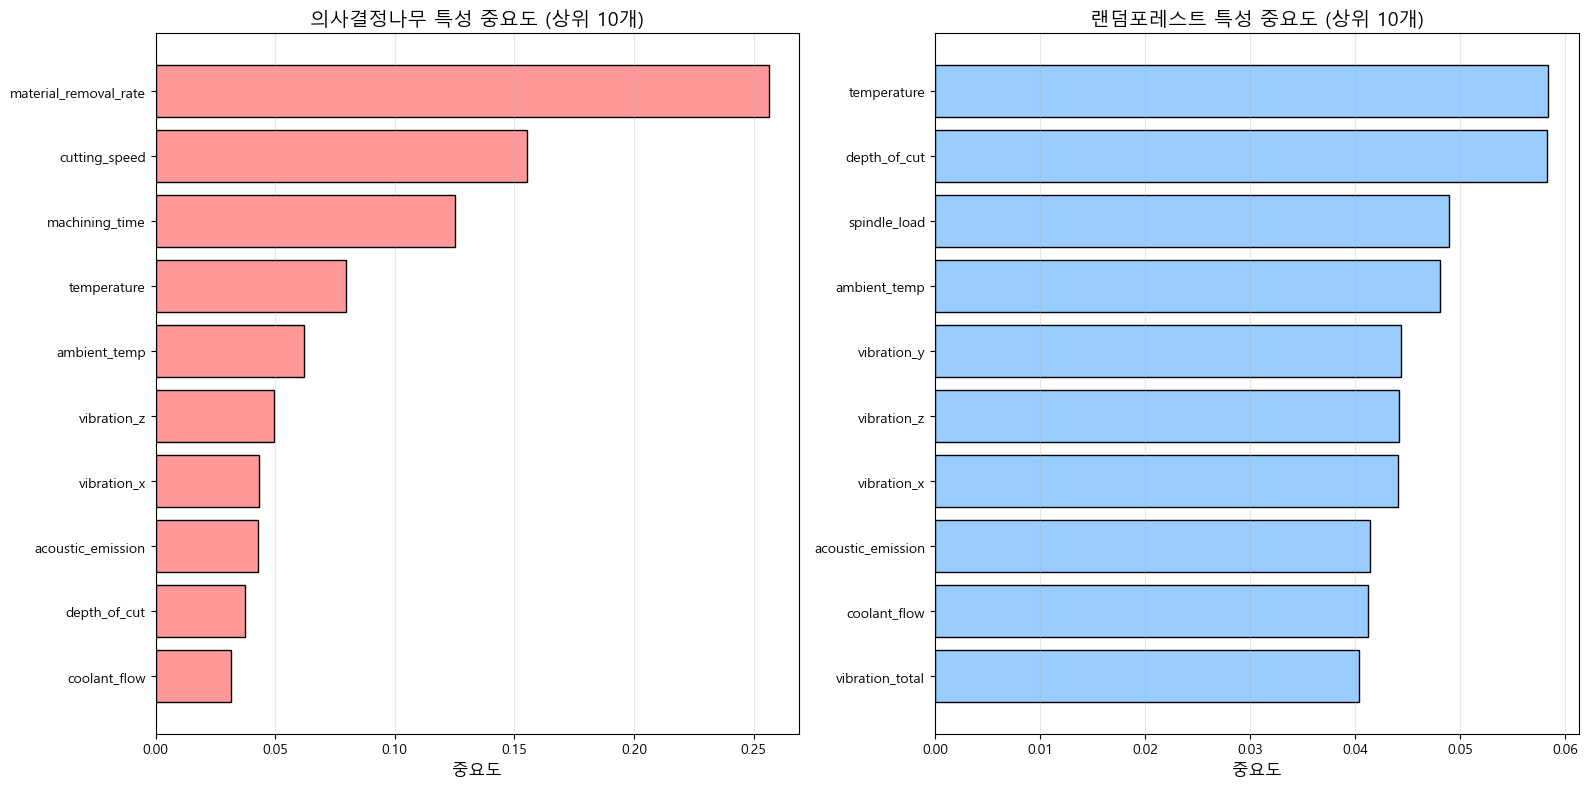


[특성 중요도 해석]
------------------------------------------------------------
의사결정나무: 특정 특성에 중요도가 집중되는 경향
  - 최고 중요도: 0.2562
  - 상위 3개 특성이 차지하는 비율: 53.6%

랜덤포레스트: 여러 특성에 중요도가 분산됨
  - 최고 중요도: 0.1390
  - 상위 3개 특성이 차지하는 비율: 36.7%


In [26]:
# 특성 중요도 시각화
fig, axes = plt.subplots(1, 2, figsize=(16, 8))

# 의사결정나무
ax1 = axes[0]
dt_sorted_idx = np.argsort(dt_importances)[::-1][:10]
bars1 = ax1.barh(range(10), dt_importances[dt_sorted_idx][::-1], color='#FF9999', edgecolor='black')
ax1.set_yticks(range(10))
ax1.set_yticklabels([X.columns[i] for i in dt_sorted_idx[::-1]])
ax1.set_xlabel('중요도', fontsize=12)
ax1.set_title('의사결정나무 특성 중요도 (상위 10개)', fontsize=14)
ax1.grid(True, axis='x', alpha=0.3)

# 랜덤포레스트
ax2 = axes[1]
bars2 = ax2.barh(range(10), rf_importances[rf_sorted_idx][::-1][:10], color='#99CCFF', edgecolor='black')
ax2.set_yticks(range(10))
ax2.set_yticklabels([X.columns[i] for i in rf_sorted_idx[::-1][:10]])
ax2.set_xlabel('중요도', fontsize=12)
ax2.set_title('랜덤포레스트 특성 중요도 (상위 10개)', fontsize=14)
ax2.grid(True, axis='x', alpha=0.3)

plt.tight_layout()
plt.show()

# 해석
print("\n[특성 중요도 해석]")
print("-" * 60)
print("의사결정나무: 특정 특성에 중요도가 집중되는 경향")
print(f"  - 최고 중요도: {max(dt_importances):.4f}")
print(f"  - 상위 3개 특성이 차지하는 비율: {sum(sorted(dt_importances)[-3:]):.1%}")
print("\n랜덤포레스트: 여러 특성에 중요도가 분산됨")
print(f"  - 최고 중요도: {max(rf_importances):.4f}")
print(f"  - 상위 3개 특성이 차지하는 비율: {sum(sorted(rf_importances)[-3:]):.1%}")

## 3.9 개별 트리 예측 분포 분석

In [27]:
# 개별 트리 정보 확인
print("=" * 60)
print(f"랜덤포레스트 구성 정보")
print("=" * 60)
print(f"총 트리 개수: {len(rf.estimators_)}")

# 트리별 깊이와 리프 수 통계
depths = [tree.get_depth() for tree in rf.estimators_]
leaves = [tree.get_n_leaves() for tree in rf.estimators_]

print(f"\n[개별 트리 통계]")
print(f"  트리 깊이 - 평균: {np.mean(depths):.1f}, 범위: {min(depths)} ~ {max(depths)}")
print(f"  리프 노드 수 - 평균: {np.mean(leaves):.1f}, 범위: {min(leaves)} ~ {max(leaves)}")

랜덤포레스트 구성 정보
총 트리 개수: 100

[개별 트리 통계]
  트리 깊이 - 평균: 10.0, 범위: 10 ~ 10
  리프 노드 수 - 평균: 174.1, 범위: 125 ~ 211


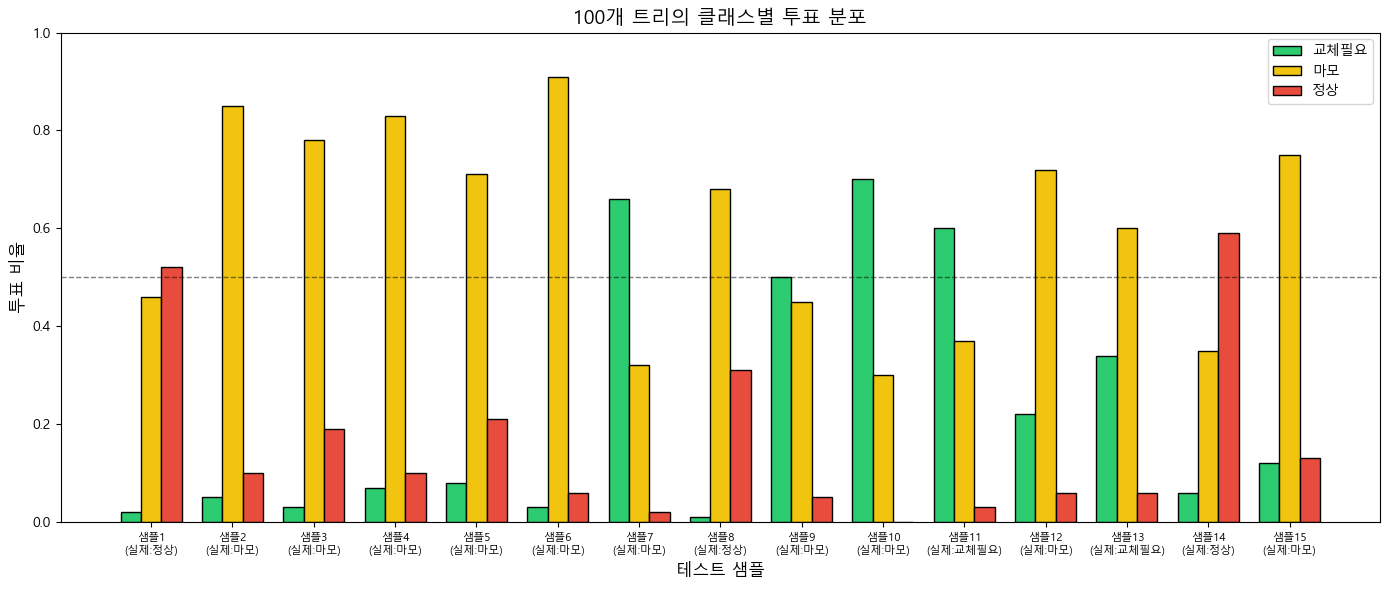

In [28]:
# 개별 트리 예측 분포 시각화
n_samples_show = 15
sample_indices = np.random.choice(len(X_test), n_samples_show, replace=False)
sample_data = X_test.iloc[sample_indices]
sample_actual = y_test[sample_indices]

# 각 트리의 예측 수집
tree_predictions = np.array([tree.predict(sample_data) for tree in rf.estimators_])

# 클래스별 투표 비율 계산
vote_distributions = []
for i in range(n_samples_show):
    votes = tree_predictions[:, i]
    dist = [np.sum(votes == c) / len(votes) for c in range(3)]
    vote_distributions.append(dist)

vote_df = pd.DataFrame(vote_distributions, columns=le.classes_)

# 시각화
fig, ax = plt.subplots(figsize=(14, 6))

x = np.arange(n_samples_show)
width = 0.25

colors = ['#2ecc71', '#f1c40f', '#e74c3c']
for i, (cls, color) in enumerate(zip(le.classes_, colors)):
    ax.bar(x + i*width, vote_df[cls], width, label=cls, color=color, edgecolor='black')

ax.set_xlabel('테스트 샘플', fontsize=12)
ax.set_ylabel('투표 비율', fontsize=12)
ax.set_title('100개 트리의 클래스별 투표 분포', fontsize=14)
ax.set_xticks(x + width)
ax.set_xticklabels([f'샘플{i+1}\n(실제:{le.classes_[sample_actual[i]]})' for i in range(n_samples_show)], fontsize=8)
ax.legend(loc='upper right')
ax.axhline(y=0.5, color='black', linestyle='--', linewidth=1, alpha=0.5)
ax.set_ylim([0, 1])

plt.tight_layout()
plt.show()

## 3.10 새로운 데이터 예측

In [29]:
# 새로운 가공 조건에 대한 예측
new_machining_data = pd.DataFrame({
    'cutting_speed': [100, 180, 90, 160, 120],
    'feed_rate': [0.08, 0.25, 0.10, 0.20, 0.15],
    'depth_of_cut': [1.0, 2.5, 0.8, 2.0, 1.5],
    'machining_time': [10, 50, 5, 40, 25],
    'spindle_load': [30, 70, 25, 60, 45],
    'vibration_x': [0.5, 3.5, 0.3, 2.8, 1.5],
    'vibration_y': [0.6, 3.2, 0.4, 2.5, 1.6],
    'vibration_z': [0.4, 2.8, 0.2, 2.2, 1.2],
    'temperature': [35, 75, 28, 65, 50],
    'acoustic_emission': [2, 8, 1.5, 6, 4],
    'coolant_flow': [15, 8, 20, 10, 12],
    'ambient_temp': [22, 25, 20, 24, 23]
})

# 파생 특성 추가
new_machining_data['vibration_total'] = np.sqrt(
    new_machining_data['vibration_x']**2 + 
    new_machining_data['vibration_y']**2 + 
    new_machining_data['vibration_z']**2
)
new_machining_data['material_removal_rate'] = (
    new_machining_data['cutting_speed'] * 
    new_machining_data['feed_rate'] * 
    new_machining_data['depth_of_cut']
)
new_machining_data['specific_cutting_energy'] = (
    new_machining_data['spindle_load'] / 
    (new_machining_data['material_removal_rate'] + 0.1)
)

print("=" * 70)
print("새로운 가공 조건 예측")
print("=" * 70)

# 예측
predictions = rf.predict(new_machining_data)
probabilities = rf.predict_proba(new_machining_data)

print("\n[입력 조건 및 예측 결과]")
print("-" * 70)
print(f"{'조건':>4} | {'절삭속도':>8} | {'이송':>6} | {'깊이':>5} | {'시간':>5} | {'예측':>8} | {'확신도':>8}")
print("-" * 70)

for i in range(len(new_machining_data)):
    pred_label = le.classes_[predictions[i]]
    confidence = max(probabilities[i]) * 100
    
    print(f"{i+1:>4} | {new_machining_data['cutting_speed'].iloc[i]:>8.0f} | "
          f"{new_machining_data['feed_rate'].iloc[i]:>6.2f} | "
          f"{new_machining_data['depth_of_cut'].iloc[i]:>5.1f} | "
          f"{new_machining_data['machining_time'].iloc[i]:>5.0f} | "
          f"{pred_label:>8} | {confidence:>7.1f}%")

print("-" * 70)
print("\n[상세 확률 분포]")
for i in range(len(new_machining_data)):
    print(f"조건 {i+1}: " + " | ".join([f"{le.classes_[j]}: {probabilities[i][j]:.1%}" for j in range(3)]))

새로운 가공 조건 예측

[입력 조건 및 예측 결과]
----------------------------------------------------------------------
  조건 |     절삭속도 |     이송 |    깊이 |    시간 |       예측 |      확신도
----------------------------------------------------------------------
   1 |      100 |   0.08 |   1.0 |    10 |       정상 |    82.0%
   2 |      180 |   0.25 |   2.5 |    50 |     교체필요 |    91.8%
   3 |       90 |   0.10 |   0.8 |     5 |       정상 |    83.9%
   4 |      160 |   0.20 |   2.0 |    40 |     교체필요 |    49.3%
   5 |      120 |   0.15 |   1.5 |    25 |       마모 |    77.5%
----------------------------------------------------------------------

[상세 확률 분포]
조건 1: 교체필요: 0.0% | 마모: 18.0% | 정상: 82.0%
조건 2: 교체필요: 91.8% | 마모: 8.1% | 정상: 0.0%
조건 3: 교체필요: 1.0% | 마모: 15.1% | 정상: 83.9%
조건 4: 교체필요: 49.3% | 마모: 47.0% | 정상: 3.6%
조건 5: 교체필요: 2.6% | 마모: 77.5% | 정상: 19.9%


---

# 핵심 정리

---

## 앙상블 학습 핵심 개념

| 개념 | 설명 |
|------|------|
| **앙상블** | 여러 모델 결합으로 성능 향상 |
| **배깅** | 병렬 학습 + 투표/평균, 분산 감소 |
| **랜덤포레스트** | 배깅 + 특성 랜덤 선택 |
| **부트스트랩** | 복원 추출로 다양한 데이터셋 생성 |
| **OOB 점수** | 사용되지 않은 데이터로 성능 평가 |

## 수학 공식 정리

| 공식 | 설명 |
|------|------|
| $\hat{y} = \text{mode}\{f_1(x), \ldots, f_B(x)\}$ | 분류: 다수결 투표 |
| $\hat{y} = \frac{1}{B}\sum_{b=1}^{B}f_b(x)$ | 회귀: 평균 |
| $P = (1-\frac{1}{n})^n \approx e^{-1} \approx 0.368$ | 부트스트랩 제외 확률 |
| $Var = \rho\sigma^2 + \frac{1-\rho}{B}\sigma^2$ | 상관된 앙상블 분산 |

## 주요 하이퍼파라미터

| 파라미터 | 권장값 | 설명 |
|----------|--------|------|
| `n_estimators` | 100~200 | 트리 개수, 많을수록 안정적 |
| `max_depth` | None 또는 10~20 | 트리 최대 깊이 |
| `max_features` | 'sqrt' | 분할 시 고려할 특성 수 |
| `min_samples_leaf` | 1~5 | 리프 노드 최소 샘플 수 |
| `oob_score` | True | OOB 점수 계산 여부 |
| `n_jobs` | -1 | 병렬 처리 CPU 코어 수 |

---

## 실무 적용 가이드라인

### 언제 랜덤포레스트를 사용할까?

| 상황 | 권장 여부 | 이유 |
|------|----------|------|
| 빠른 프로토타이핑 | 강력 추천 | 튜닝 없이도 좋은 성능 |
| 특성 중요도 분석 필요 | 강력 추천 | 안정적인 중요도 추정 |
| 안정적인 예측 필요 | 추천 | 분산이 낮음 |
| 결측치가 있는 데이터 | 추천 | 상대적으로 강건 |
| 해석이 매우 중요 | 주의 | 단일 트리보다 해석 어려움 |
| 실시간 예측 필요 | 주의 | 예측 속도가 단일 모델보다 느림 |
| 최고 성능 필요 | 비교 필요 | XGBoost, LightGBM과 비교 |

# 추가 학습 자료

본 섹션은 시간이 허락할 경우 또는 심화 학습을 원하는 경우 참고할 수 있는 내용임.

## 참고 1: 순열 중요도 (Permutation Importance)

기본 특성 중요도(불순도 기반)보다 더 신뢰할 수 있는 방법임.

In [30]:
# 순열 중요도 계산 (참고용)
from sklearn.inspection import permutation_importance

print("순열 중요도 계산 중... (약간의 시간이 소요됨)")
perm_importance = permutation_importance(rf, X_test, y_test, n_repeats=10, random_state=42, n_jobs=-1)

print("\n[순열 중요도 상위 10개]")
print("-" * 55)
sorted_idx = perm_importance.importances_mean.argsort()[::-1]
for i, idx in enumerate(sorted_idx[:10], 1):
    print(f"{i:>2}. {X.columns[idx]:>25}: {perm_importance.importances_mean[idx]:.4f} "
          f"(+/- {perm_importance.importances_std[idx]:.4f})")

순열 중요도 계산 중... (약간의 시간이 소요됨)

[순열 중요도 상위 10개]
-------------------------------------------------------
 1.             cutting_speed: 0.0617 (+/- 0.0145)
 2.     material_removal_rate: 0.0442 (+/- 0.0094)
 3.                 feed_rate: 0.0157 (+/- 0.0075)
 4.            machining_time: 0.0122 (+/- 0.0067)
 5.   specific_cutting_energy: 0.0115 (+/- 0.0059)
 6.               temperature: 0.0057 (+/- 0.0092)
 7.               vibration_z: 0.0012 (+/- 0.0042)
 8.               vibration_x: 0.0002 (+/- 0.0075)
 9.              depth_of_cut: -0.0003 (+/- 0.0075)
10.              coolant_flow: -0.0010 (+/- 0.0050)


## 참고 2: 하이퍼파라미터 튜닝 (GridSearchCV)

In [ ]:
# GridSearchCV 예시 코드 (참고용, 실행 시 시간 소요)
from sklearn.model_selection import GridSearchCV

# 파라미터 그리드 정의
param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [10, 15, None],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2]
}

# 시간 관계상 작은 샘플로 시연
X_sample, _, y_sample, _ = train_test_split(X, y, train_size=500, random_state=42, stratify=y)

rf_grid = RandomForestClassifier(random_state=42, n_jobs=-1)
grid_search = GridSearchCV(rf_grid, param_grid, cv=3, scoring='accuracy', n_jobs=-1, verbose=1)

print("GridSearchCV 실행 중...")
grid_search.fit(X_sample, y_sample)

print(f"\n최적 파라미터: {grid_search.best_params_}")
print(f"최적 교차검증 점수: {grid_search.best_score_:.4f}")

## 참고 3: 랜덤포레스트 vs 다른 앙상블 기법 비교

| 기법 | 특징 | 장점 | 단점 | 적합한 상황 |
|------|------|------|------|------------|
| **랜덤포레스트** | 병렬 배깅 | 안정적, 튜닝 적음 | 속도 보통 | 일반적인 분류/회귀 |
| **XGBoost** | 순차 부스팅 | 최고 성능 가능 | 튜닝 복잡 | 대회, 정교한 예측 |
| **LightGBM** | 리프 중심 성장 | 빠른 학습 | 과적합 주의 | 대용량 데이터 |
| **CatBoost** | 범주형 처리 | 범주형 특성에 강함 | 메모리 사용 | 범주형 특성 많을 때 |